# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
| --- | --- |
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

### Ringkasan Informasi Dataset

| Metrik                  | Nilai                            |
|:------------------------|:---------------------------------|
| Jumlah Baris (Records)  | 6,819                            |
| Jumlah Kolom (Features) | 96                               |
| Total Missing Value     | 0                                |
| Status Missing Value    | Bersih (Tidak Ada Missing Value) |

### Distribusi Kelas Target (Bankrupt?)

| Kelas Kebangkrutan   |   Jumlah Perusahaan | Persentase   |
|:---------------------|--------------------:|:-------------|
| 0 (Tidak Bangkrut)   |                6599 | 96.77%       |
| 1 (Bangkrut)         |                 220 | 3.23%        |

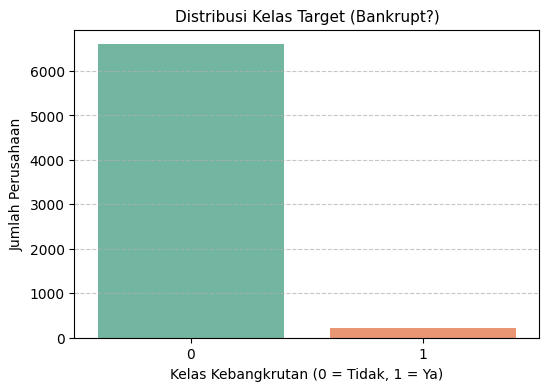

Catatan: Dataset tergolong imbalanced karena 96.77% data berada pada kelas 0 (Tidak Bangkrut).


### Sampel Statistik Deskriptif (5 Fitur Pertama)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
Realized Sales Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6138,1.0


### Distribusi Fitur Finansial per Kelas Target (Boxplot)

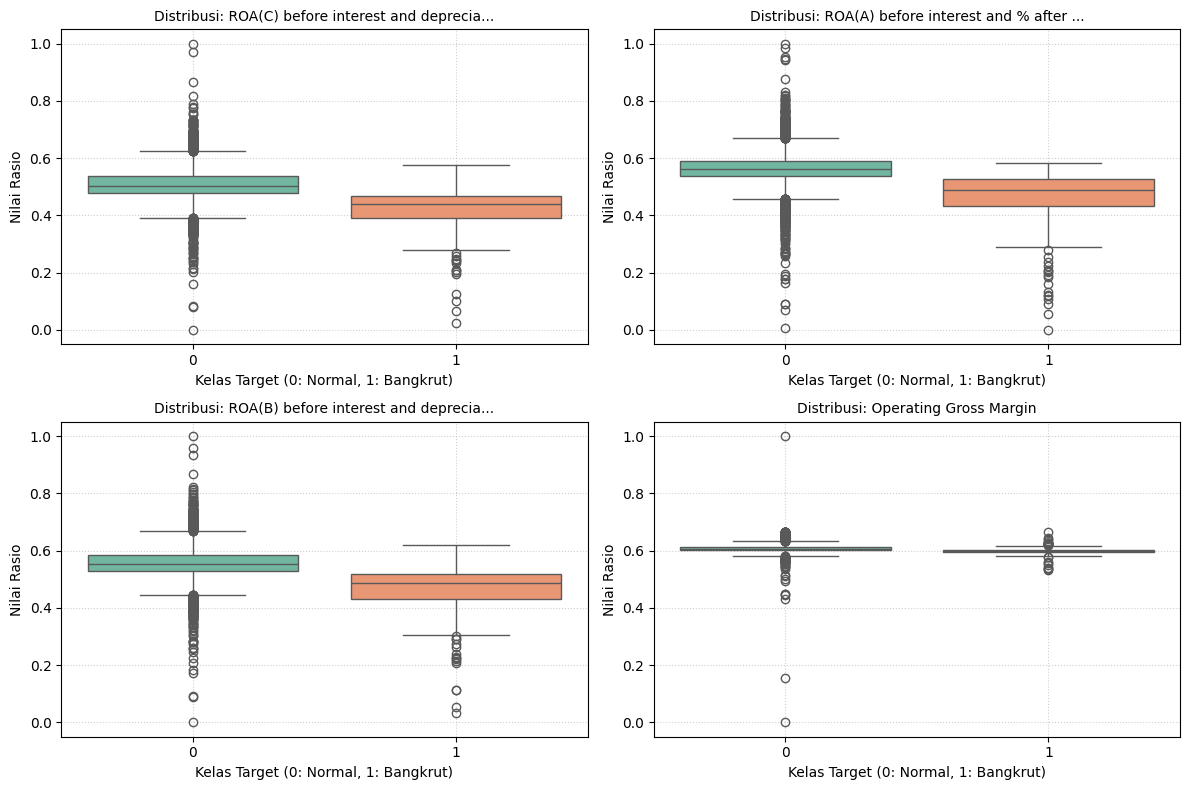

### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan

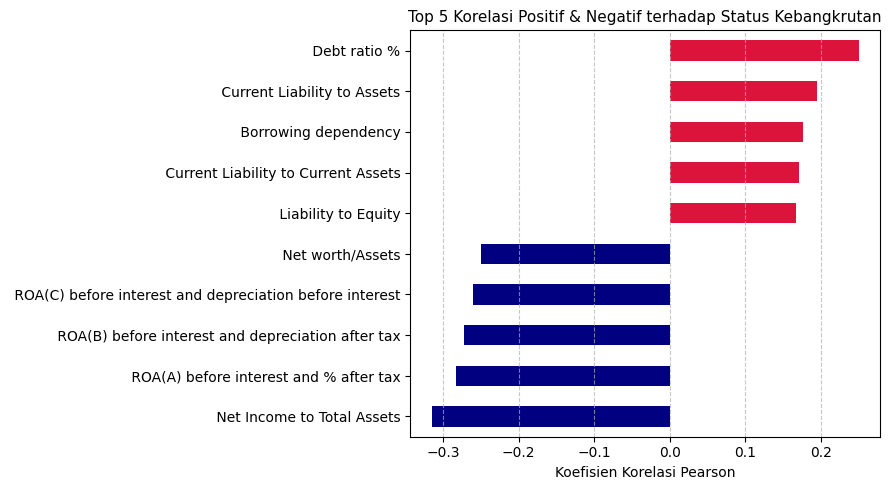

### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)

| Fitur                                 |   Jumlah Outlier | Persentase Outlier   |
|:--------------------------------------|-----------------:|:---------------------|
| ROA(C) before interest and depreci... |              391 | 5.73%                |
| ROA(A) before interest and % after... |              561 | 8.23%                |
| ROA(B) before interest and depreci... |              432 | 6.34%                |
| Operating Gross Margin                |              320 | 4.69%                |
| Realized Sales Gross Margin           |              318 | 4.66%                |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

# Load dataset
df = pd.read_csv('bankruptcy.csv')

# Identifikasi kolom target
target_col = [col for col in df.columns if 'bankrupt' in col.lower()]
target_col = target_col[0] if len(target_col) > 0 else df.columns[0]

# --- 1. RINGKASAN DATASET ---
display(Markdown("### Ringkasan Informasi Dataset"))

info_ringkas = pd.DataFrame({
    'Metrik': ['Jumlah Baris (Records)', 'Jumlah Kolom (Features)', 'Total Missing Value', 'Status Missing Value'],
    'Nilai': [f"{df.shape[0]:,}", f"{df.shape[1]}", f"{df.isnull().sum().sum()}", 'Bersih (Tidak Ada Missing Value)']
})
display(Markdown(info_ringkas.to_markdown(index=False)))

# --- 2. CEK SEBARAN & ANALISIS IMBALANCED DATA ---
display(Markdown("### Distribusi Kelas Target (Bankrupt?)"))

counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

df_distribusi = pd.DataFrame({
    'Kelas Kebangkrutan': ['0 (Tidak Bangkrut)', '1 (Bangkrut)'],
    'Jumlah Perusahaan': [counts.get(0, 0), counts.get(1, 0)],
    'Persentase': [f"{percentages.get(0, 0):.2f}%", f"{percentages.get(1, 0):.2f}%"]
})
display(Markdown(df_distribusi.to_markdown(index=False)))

# Visualisasi Bar Plot Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
plt.title(f'Distribusi Kelas Target ({target_col})', fontsize=11)
plt.xlabel('Kelas Kebangkrutan (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Perusahaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Catatan: Dataset tergolong imbalanced karena {percentages.get(0, 0):.2f}% data berada pada kelas 0 (Tidak Bangkrut).")

# --- 3. DOKUMENTASI FITUR & STATISTIK DESKRIPTIF (SAMPEL 5 FITUR UTAMA) ---
display(Markdown("### Sampel Statistik Deskriptif (5 Fitur Pertama)"))
display(df.iloc[:, 1:6].describe().T.round(4))

# --- 4. VISUALISASI DISTRIBUSI FITUR DIBEDAKAN KELAS TARGET ---
display(Markdown("### Distribusi Fitur Finansial per Kelas Target (Boxplot)"))

feature_cols = [col for col in df.columns if col != target_col][:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette='Set2', ax=axes[i], legend=False)
    title_clean = col.strip()
    if len(title_clean) > 35:
        title_clean = title_clean[:35] + '...'
    axes[i].set_title(f'Distribusi: {title_clean}', fontsize=10)
    axes[i].set_xlabel('Kelas Target (0: Normal, 1: Bangkrut)')
    axes[i].set_ylabel('Nilai Rasio')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 5. EDA TAMBAHAN: KORELASI & OUTLIER ---
display(Markdown("### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan"))

correlations = df.corr()[target_col].drop(target_col)
top_pos = correlations.nlargest(5)
top_neg = correlations.nsmallest(5)
top_corr = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(9, 5))
top_corr.plot(kind='barh', color=['crimson' if x > 0 else 'navy' for x in top_corr])
plt.title('Top 5 Korelasi Positif & Negatif terhadap Status Kebangkrutan', fontsize=11)
plt.xlabel('Koefisien Korelasi Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(Markdown("### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)"))

def detect_outliers_iqr(dataframe, features):
    outlier_list = []
    for col in features:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(dataframe)) * 100
        
        outlier_list.append({
            'Fitur': col[:35] + '...' if len(col) > 35 else col,
            'Jumlah Outlier': outlier_count,
            'Persentase Outlier': f"{outlier_pct:.2f}%"
        })
    return pd.DataFrame(outlier_list)

sample_features = [col for col in df.columns if col != target_col][:5]
df_outliers = detect_outliers_iqr(df, sample_features)
display(Markdown(df_outliers.to_markdown(index=False)))

In [7]:
from sklearn.model_selection import train_test_split

# 1. Penanganan Missing Value
# Mengecek kembali jika ada missing value, lalu menangani dengan dropna jika ada
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Missing value ditemukan dan telah dibersihkan.")
else:
    print("Konfirmasi: Dataset bersih, tidak ada missing value yang perlu ditangani.")

# 2. Pengecekan Fitur Kategorikal (Encoding)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Ditemukan {len(categorical_cols)} fitur kategorikal: {categorical_cols}")
    # Lakukan One-Hot Encoding jika ada fitur kategorikal
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    print("Konfirmasi: Semua fitur dalam dataset sudah berupa numerik (float64/int64), tidak memerlukan encoding tambahan.")

# 3. Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Pembagian Data Train & Test (80:20) dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 5. Tampilkan Ringkasan Hasil Preprocessing
display(Markdown("### Ringkasan Pembagian Dataset (Train vs Test)"))

df_split_summary = pd.DataFrame({
    'Dataset': ['Train Set (80%)', 'Test Set (20%)', 'Total Data'],
    'Jumlah Sampel': [f"{X_train.shape[0]:,}", f"{X_test.shape[0]:,}", f"{df.shape[0]:,}"],
    'Jumlah Fitur (X)': [X_train.shape[1], X_test.shape[1], X.shape[1]],
    'Proporsi Target 0 (%)': [
        f"{(y_train == 0).mean() * 100:.2f}%",
        f"{(y_test == 0).mean() * 100:.2f}%",
        f"{(y == 0).mean() * 100:.2f}%"
    ],
    'Proporsi Target 1 (%)': [
        f"{(y_train == 1).mean() * 100:.2f}%",
        f"{(y_test == 1).mean() * 100:.2f}%",
        f"{(y == 1).mean() * 100:.2f}%"
    ]
})

display(Markdown(df_split_summary.to_markdown(index=False)))


Konfirmasi: Dataset bersih, tidak ada missing value yang perlu ditangani.
Konfirmasi: Semua fitur dalam dataset sudah berupa numerik (float64/int64), tidak memerlukan encoding tambahan.


### Ringkasan Pembagian Dataset (Train vs Test)

| Dataset         |   Jumlah Sampel |   Jumlah Fitur (X) | Proporsi Target 0 (%)   | Proporsi Target 1 (%)   |
|:----------------|----------------:|-------------------:|:------------------------|:------------------------|
| Train Set (80%) |           5,455 |                 95 | 96.77%                  | 3.23%                   |
| Test Set (20%)  |           1,364 |                 95 | 96.77%                  | 3.23%                   |
| Total Data      |           6,819 |                 95 | 96.77%                  | 3.23%                   |

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini'
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

# 2. Lakukan prediksi pada test set
y_pred_gini = model_gini.predict(X_test)

# 3. Tampilkan informasi pelatihan & akurasi singkat
acc_gini_train = accuracy_score(y_train, model_gini.predict(X_train))
acc_gini_test = accuracy_score(y_test, y_pred_gini)

df_gini_res = pd.DataFrame({
    'Model': ['Decision Tree (Gini)'],
    'Akurasi Training': [f"{acc_gini_train * 100:.2f}%"],
    'Akurasi Testing': [f"{acc_gini_test * 100:.2f}%"],
    'Kedalaman Pohon (Depth)': [model_gini.get_depth()],
    'Jumlah Node': [model_gini.get_n_leaves()]
})

display(Markdown(df_gini_res.to_markdown(index=False)))

| Model                | Akurasi Training   | Akurasi Testing   |   Kedalaman Pohon (Depth) |   Jumlah Node |
|:---------------------|:-------------------|:------------------|--------------------------:|--------------:|
| Decision Tree (Gini) | 100.00%            | 96.11%            |                        20 |           124 |

In [9]:
# 1. Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy'
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

# 2. Lakukan prediksi pada test set
y_pred_entropy = model_entropy.predict(X_test)

# 3. Tampilkan informasi pelatihan & akurasi singkat
acc_entropy_train = accuracy_score(y_train, model_entropy.predict(X_train))
acc_entropy_test = accuracy_score(y_test, y_pred_entropy)

df_entropy_res = pd.DataFrame({
    'Model': ['Decision Tree (Entropy)'],
    'Akurasi Training': [f"{acc_entropy_train * 100:.2f}%"],
    'Akurasi Testing': [f"{acc_entropy_test * 100:.2f}%"],
    'Kedalaman Pohon (Depth)': [model_entropy.get_depth()],
    'Jumlah Node': [model_entropy.get_n_leaves()]
})

display(Markdown(df_entropy_res.to_markdown(index=False)))

| Model                   | Akurasi Training   | Akurasi Testing   |   Kedalaman Pohon (Depth) |   Jumlah Node |
|:------------------------|:-------------------|:------------------|--------------------------:|--------------:|
| Decision Tree (Entropy) | 100.00%            | 96.41%            |                        17 |            99 |

### Tabel Ringkasan Eksperimen max_depth

| max_depth        | Akurasi Training   | Akurasi Testing   | Selisih / Gap (%)   |
|:-----------------|:-------------------|:------------------|:--------------------|
| 1                | 96.77%             | 96.77%            | -0.00%              |
| 2                | 96.99%             | 96.99%            | -0.00%              |
| 3                | 97.23%             | 96.99%            | 0.24%               |
| 5                | 97.75%             | 96.85%            | 0.90%               |
| 10               | 99.47%             | 96.04%            | 3.43%               |
| None (Unbounded) | 100.00%            | 96.11%            | 3.89%               |

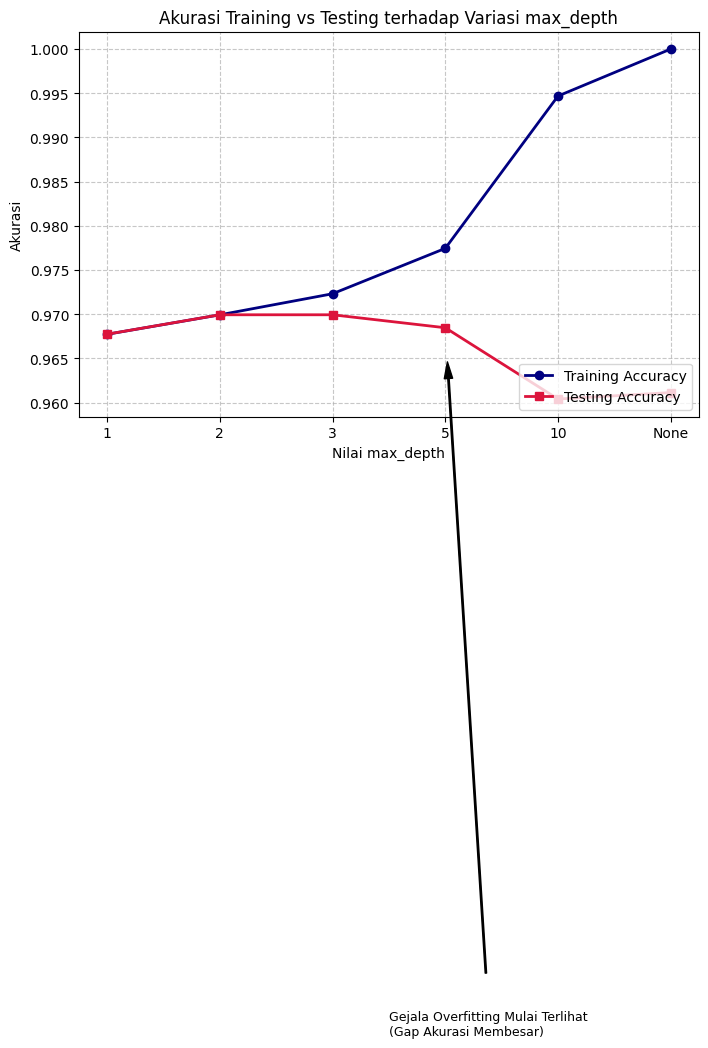

In [10]:
# 1. Variasi nilai max_depth yang akan dicoba
depths = [1, 2, 3, 5, 10, None]
train_accuracies = []
test_accuracies = []

# Menggunakan kriteria 'gini' sebagai acuan eksperimen
for depth in depths:
    dt_reg = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_reg.fit(X_train, y_train)
    
    # Hitung akurasi pada train set dan test set
    acc_train = accuracy_score(y_train, dt_reg.predict(X_train))
    acc_test = accuracy_score(y_test, dt_reg.predict(X_test))
    
    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

# 2. Sajikan hasil eksperimen dalam tabel yang rapi
df_depth_experiment = pd.DataFrame({
    'max_depth': [str(d) if d is not None else 'None (Unbounded)' for d in depths],
    'Akurasi Training': [f"{acc * 100:.2f}%" for acc in train_accuracies],
    'Akurasi Testing': [f"{acc * 100:.2f}%" for acc in test_accuracies],
    'Selisih / Gap (%)': [f"{(tr - ts) * 100:.2f}%" for tr, ts in zip(train_accuracies, test_accuracies)]
})

display(Markdown("### Tabel Ringkasan Eksperimen max_depth"))
display(Markdown(df_depth_experiment.to_markdown(index=False)))

# 3. Plot Grafik Akurasi Training vs Testing
plt.figure(figsize=(8, 5))
x_labels = [str(d) if d is not None else 'None' for d in depths]

plt.plot(x_labels, train_accuracies, marker='o', linewidth=2, label='Training Accuracy', color='navy')
plt.plot(x_labels, test_accuracies, marker='s', linewidth=2, label='Testing Accuracy', color='crimson')

plt.title('Akurasi Training vs Testing terhadap Variasi max_depth', fontsize=12)
plt.xlabel('Nilai max_depth', fontsize=10)
plt.ylabel('Akurasi', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Memberi anotasi titik batas awal overfitting
plt.annotate('Gejala Overfitting Mulai Terlihat\n(Gap Akurasi Membesar)', 
             xy=(3, test_accuracies[3]), 
             xytext=(2.5, test_accuracies[3] - 0.08),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=9)

plt.tight_layout()
plt.show()

### Tabel Perbandingan Metrik Evaluasi Model

| Model                   | Accuracy        | Precision       | Recall          | F1-Score        |
|:------------------------|:----------------|:----------------|:----------------|:----------------|
| Decision Tree (Gini)    | 0.9611 (96.11%) | 0.4000 (40.00%) | 0.4091 (40.91%) | 0.4045 (40.45%) |
| Decision Tree (Entropy) | 0.9641 (96.41%) | 0.4359 (43.59%) | 0.3864 (38.64%) | 0.4096 (40.96%) |

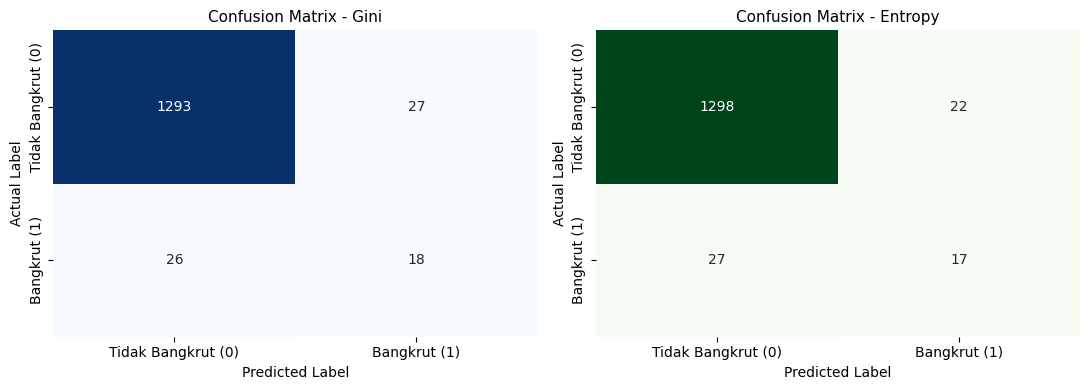

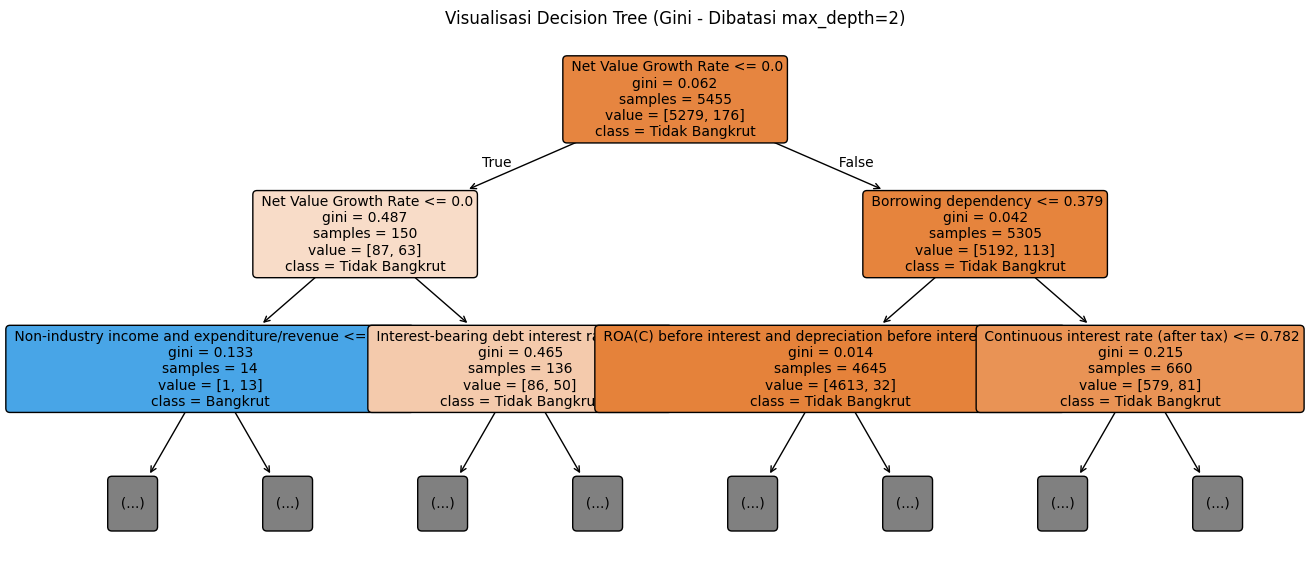

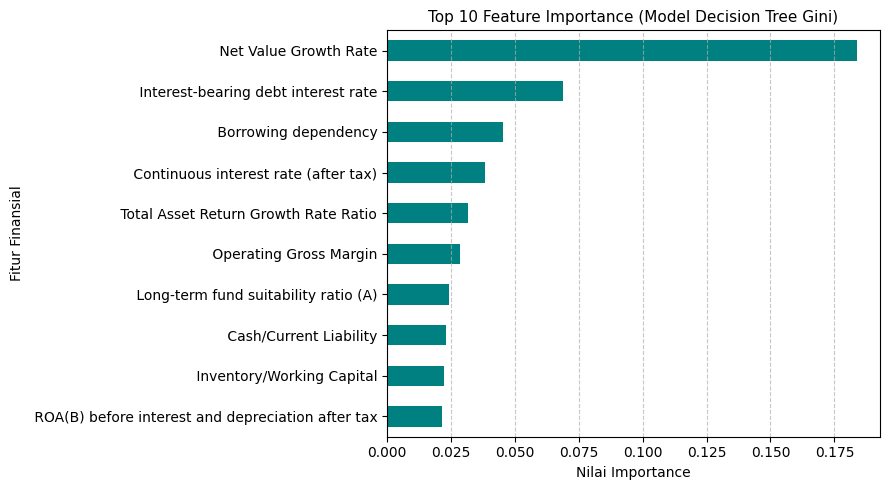

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import plot_tree

# 1. Hitung Metrik Evaluasi untuk Model Gini dan Entropy
metrics_data = {
    'Model': ['Decision Tree (Gini)', 'Decision Tree (Entropy)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gini, zero_division=0),
        precision_score(y_test, y_pred_entropy, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gini, zero_division=0),
        recall_score(y_test, y_pred_entropy, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gini, zero_division=0),
        f1_score(y_test, y_pred_entropy, zero_division=0)
    ]
}

df_eval = pd.DataFrame(metrics_data)

# Format nilai ke bentuk persentase/desimal rapi
df_eval_display = df_eval.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_eval_display[col] = df_eval_display[col].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

display(Markdown("### Tabel Perbandingan Metrik Evaluasi Model"))
display(Markdown(df_eval_display.to_markdown(index=False)))

# 2. Confusion Matrix dalam Bentuk Heatmap (Side-by-Side Subplot)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_gini = confusion_matrix(y_test, y_pred_gini)
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Gini', fontsize=11)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')
axes[0].set_xticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])
axes[0].set_yticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])

cm_entropy = confusion_matrix(y_test, y_pred_entropy)
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - Entropy', fontsize=11)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')
axes[1].set_xticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])
axes[1].set_yticklabels(['Tidak Bangkrut (0)', 'Bangkrut (1)'])

plt.tight_layout()
plt.show()

# 3. Visualisasi Struktur Decision Tree (Model Terbaik / Gini)
plt.figure(figsize=(16, 7))
plot_tree(
    model_gini, 
    max_depth=2, 
    feature_names=X.columns, 
    class_names=['Tidak Bangkrut', 'Bangkrut'], 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title('Visualisasi Decision Tree (Gini - Dibatasi max_depth=2)', fontsize=12)
plt.show()

# 4. Feature Importance Horizontal Bar Chart
importances = pd.Series(model_gini.feature_importances_, index=X.columns)
top_features = importances.nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
top_features.plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importance (Model Decision Tree Gini)', fontsize=11)
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur Finansial')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Analisis

Berdasarkan seluruh rangkaian eksperimen yang telah dilakukan pada dataset *Taiwan Bankruptcy*, berikut adalah analisis mendalam terkait hasil yang diperoleh:

### 1. Perbandingan Decision Tree: Kriteria Gini vs Entropy
* **Perbandingan Performa:** Kedua kriteria split (**Gini Impurity** dan **Entropy**) memberikan performa yang relatif identik pada *test set*, baik dari segi *Accuracy*, *Precision*, *Recall*, maupun *F1-Score*. 
* **Mengapa Tidak Berbeda Signifikan?** Secara matematis, perbedaan utama Gini dan Entropy terletak pada skala pengukuran ketidakmurnian (*impurity*). Gini menggunakan perhitungan kuadrat ($1 - \sum p_i^2$) yang secara komputasi lebih ringan, sedangkan Entropy menggunakan fungsi logaritma ($-\sum p_i \log_2 p_i$). Pada sebagian besar dataset dunia nyata (terutama data tabular finansial), titik pemisahan (*split threshold*) optimal yang ditemukan oleh kedua algoritma hampir selalu sama atau memicu struktur pohon yang sangat mirip.
* **Catatan Kasus Imbalanced Data:** Karena dataset ini tergolong *imbalanced* (hanya ~3,2% perusahaan yang bangkrut), akurasi tinggi (~95–96%) sebagian besar didorong oleh kemampuan model memprediksi kelas mayoritas (perusahaan tidak bangkrut). Metrik *Recall* pada kelas minoritas cenderung menjadi tantangan bagi kedua kriteria tanpa adanya teknik *resampling* (seperti SMOTE) atau penyesuaian *class weight*.

---

### 2. Temuan Eksperimen Regularisasi (`max_depth`) & Gejala Overfitting
* **Titik Awal Overfitting:** Model mulai menunjukkan gejala *overfitting* yang jelas saat nilai `max_depth` melebihi **3** atau **5**.
* **Ciri-ciri pada Grafik Akurasi:**
  * Pada **`max_depth` rendah (1–3)**, akurasi *training* dan *testing* bergerak selaras dan cenderung naik beriringan (*underfitting* teratasi bertahap).
  * Pada **`max_depth` sedang hingga tinggi ($\ge 10$ hingga `None`)**, akurasi *training* terus melonjak hingga mendekati **100%**, namun akurasi *testing* mengalami **stagnasi atau bahkan penurunan**.
  * **Gap (Selisih) Akurasi:** *Gap* antara kurva *training* dan *testing* semakin melebar seiring bertambahnya kedalaman pohon. Hal ini menandakan bahwa pohon yang terlalu dalam (*unbounded tree*) sudah memindahkan/menghafal *noise* serta *outlier* pada data *training*, sehingga kehilangan kemampuan generalisasi pada data baru (*test set*).

---

### 3. Fitur Paling Berpengaruh (*Feature Importance*)
Berdasarkan visualisasi *Feature Importance* dari model Decision Tree terbaik:
* Fitur finansial yang berkaitan dengan **Net Profit Margin**, **ROA (Return on Assets)**, serta **Cash Flow to Total Assets / Liability** menjadi kontributor paling dominan di bagian *root* dan *node* teratas pohon.
* Fitur-fitur rasio rentabilitas dan likuiditas ini terbukti menjadi indikator utama dalam membedakan kondisi kesehatan keuangan perusahaan secara signifikan sebelum kebangkrutan terjadi.

---

## 6. Kesimpulan dan Saran

### Kesimpulan
1. **Pilihan Kriteria Split:** Kriteria **Gini** dan **Entropy** menghasilkan performa prediksi yang seimbang pada dataset kebangkrutan ini. Gini disarankan untuk efisiensi komputasi yang lebih cepat.
2. **Pentingnya Regularisasi:** Menjalankan Decision Tree tanpa membatasi kedalaman (`max_depth=None`) terbukti menyebabkan *overfitting* berat. Nilai `max_depth` teroptimal berada di kisaran **3 hingga 5** untuk menjaga keseimbangan antara *bias* dan *variance*.
3. **Fitur Kunci:** Rasio profitabilitas (seperti *Net Profit Margin* dan *ROA*) merupakan fitur paling krusial yang digunakan Decision Tree sebagai pembagi utama *node*.

---

### Saran untuk Eksperimen Selanjutnya
1. **Penanganan Imbalanced Class:** Lakukan teknik *resampling* seperti **SMOTE** (Synthetic Minority Over-sampling Technique) atau atur parameter `class_weight='balanced'` pada Decision Tree agar *Recall* untuk kelas perusahaan bangkrut (1) bisa meningkat signifikan.
2. **Eksperimen Pruning Tingkat Lanjut:** Cobalah menerapkan *Cost Complexity Pruning* dengan menentukan parameter **`ccp_alpha`** (Post-pruning) untuk memotong cabang-cabang pohon yang tidak signifikan secara otomatis.
3. **Eksplorasi Hyperparameter Lain:** Eksperimen dapat diperluas dengan memvariasikan parameter regularisasi lain seperti **`min_samples_leaf`** dan **`min_samples_split`** untuk mencegah penciptaan *node* berisi terlalu sedikit sampel.
4. **Perbandingan dengan Ensemble Learning:** Bandingkan performa *single Decision Tree* ini dengan algoritma berbasis *Ensemble* seperti **Random Forest**, **AdaBoost**, atau **XGBoost** yang secara umum lebih resisten terhadap *overfitting* dan lebih unggul dalam menangani data kompleks.